In [1]:
# Run this as the VERY FIRST thing — before any imports
!pip install -q langchain langchain-community langchain-core langchain-text-splitters langchain-chroma langchain-huggingface langchain-groq chromadb rank_bm25 sentence-transformers pypdf groq pydantic pandas matplotlib seaborn tenacity python-dotenv

In [2]:
# ============================================================
# FINANCIAL INTELLIGENCE ENGINE
# Cell 1 — Environment Setup & Module Import
# ============================================================

# Install all pinned dependencies from requirements.txt
# This single command replaces multiple scattered !pip install lines.
!pip install -q -r requirements.txt

import sys
import os
from google.colab import drive

# ── Mount Google Drive ────────────────────────────────────────
print('Mounting Google Drive...')
drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/financial-intelligence-engine'
os.chdir(PROJECT_PATH)

# Force Python to resolve src/ imports from the project root.
if PROJECT_PATH not in sys.path:
    sys.path.insert(0, PROJECT_PATH)

# ── Flush Jupyter Module Cache ────────────────────────────────
# Required in Colab: stale cached module bytecode from previous runs
# causes import errors when source files change between cells.
modules_to_delete = [mod for mod in sys.modules if mod.startswith('src')]
for mod in modules_to_delete:
    del sys.modules[mod]
print(f'Module cache flushed ({len(modules_to_delete)} src.* modules cleared).')

# ── Import & Environment Setup ────────────────────────────────
print('Importing modules...')
from src.config import logger, setup_environment

# setup_environment() creates all artifact directories.
# Called once here so no other module needs to run side effects on import.
setup_environment()

from src.data_ingestion import load_and_chunk_pdfs

print(f'Working directory: {os.getcwd()}')
print('All modules imported successfully.')
print('\nSkipping PDF ingestion — Smart Load active in Cell 2.')
print('To rebuild indexes from scratch: uncomment the ingestion block in Cell 2.')

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'
Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Module cache flushed (0 src.* modules cleared).
Importing modules...
Working directory: /content/drive/MyDrive/financial-intelligence-engine
All modules imported successfully.

Skipping PDF ingestion — Smart Load active in Cell 2.
To rebuild indexes from scratch: uncomment the ingestion block in Cell 2.


In [5]:
# ============================================================
# Cell 2 — Hybrid Retrieval Engine (Smart Load or Cold Build)
# ============================================================

from src.retrieval_engine import HybridRetrievalEngine

retrieval_pipeline = HybridRetrievalEngine()

# ── SMART LOAD (default — skips re-embedding if indexes exist) ──
# On first run, uncomment the cold build block below instead.
print('Phase 2: Smart Loading Hybrid Indexes from Drive...')
ensemble_retriever = retrieval_pipeline.build_indexes()

 #── COLD BUILD (first run only — comment out after first successful run) ────
#print('Phase 2: Cold Build — Parsing PDFs and building indexes...')
#document_chunks = load_and_chunk_pdfs()
#print(f'Ingestion complete. Total chunks: {len(document_chunks)}')
#print(f'Sample metadata: {document_chunks[0].metadata}')
#ensemble_retriever = retrieval_pipeline.build_indexes(document_chunks)

# ── Retrieval Sanity Check ────────────────────────────────────
test_query = 'What were the total research and development (R&D) expenses?'
print(f'\nTesting Hybrid Search: "{test_query}"')
search_results = ensemble_retriever.invoke(test_query)

print('\n' + '='*50)
print(' RETRIEVAL CHECK PASSED')
print('='*50)
print(f'Documents retrieved : {len(search_results)}')
print(f'Top result company  : {search_results[0].metadata.get("company")}')
print(f'Source file         : {search_results[0].metadata.get("source_file")}')
print(f'Chunk ID            : {search_results[0].metadata.get("chunk_id")}')

# Company distribution check — should be roughly balanced across companies.
from collections import Counter
company_dist = Counter(d.metadata.get('company') for d in search_results)
print(f'Company distribution: {dict(company_dist)}')

# Clean snippet preview
raw_snippet = search_results[0].page_content[:200]
clean_snippet = ' '.join(raw_snippet.split())
print(f'Content snippet     : {clean_snippet}...')

2026-04-03 05:37:03 - [INFO] - financial_rag - Loading embedding model: BAAI/bge-small-en-v1.5
INFO:financial_rag:Loading embedding model: BAAI/bge-small-en-v1.5
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-03 05:37:14 - [INFO] - financial_rag - [2/4] Smart Load: Found existing indexes on disk. Bypassing embedding compute...
INFO:financial_rag:[2/4] Smart Load: Found existing indexes on disk. Bypassing embedding compute...
2026-04-03 05:37:15 - [INFO] - financial_rag - BM25 index loaded and integrity verified.
INFO:financial_rag:BM25 index loaded and integrity verified.
2026-04-03 05:37:15 - [INFO] - financial_rag - [2/4] Initializing Reciprocal Rank Fusion engine...
INFO:financial_rag:[2/4] Initializing Reciprocal Rank Fusion engine...
2026-04-03 05:37:15 - [INFO] - financial_rag - Hybrid Retrieval Engine ready.
INFO:financial_rag:Hybrid Retrieval Engine ready.


Phase 2: Smart Loading Hybrid Indexes from Drive...

Testing Hybrid Search: "What were the total research and development (R&D) expenses?"

 RETRIEVAL CHECK PASSED
Documents retrieved : 7
Top result company  : Meta
Source file         : meta_10k.pdf
Chunk ID            : meta_10k_36c031d9f0a086cc
Company distribution: {'Meta': 2, 'Microsoft': 2, 'Google': 3}
Content snippet     : engine, wearables, monetization of our products and services, youth, platform integrity and community support, and infrastructure capacity. The majority of our investments are directed toward developi...


In [6]:
# Cell 3 REPLACEMENT — Saves ~6000 tokens
# Generation pipeline already demonstrated. Loading credentials only.
import os
from dotenv import load_dotenv
from src.generation_agent import FinancialGenerationAgent

print('Loading credentials from Drive .env file...')
load_dotenv(override=True)
GROQ_API_KEY = os.getenv('GROQ_API_KEY')

if not GROQ_API_KEY:
    raise ValueError('GROQ_API_KEY not found in .env file.')
print('API key loaded successfully.')

# Initialize agent — needed for Cell 5 batch evaluation
agent = FinancialGenerationAgent(
    retriever=ensemble_retriever, 
    api_key=GROQ_API_KEY
)
print(f'Agent ready. Generator: {agent.llm.model_name}')

# Set the query variable — needed by Cell 4 and Cell 6
complex_query = (
    'Compare the key areas where Google and Meta are investing '
    'their Research and Development (R&D) budgets for 2025.'
)

# Use a pre-saved answer for visualization — no token cost
final_answer = (
    "Based on SEC 10-K filings:\n"
    "* Meta is investing in neural interfaces, virtual and augmented "
    "reality devices, and foundational AI research [Source: Meta 10-K]\n"
    "* Google is investing in technical infrastructure including servers "
    "and data centers, and AI-powered products like Demand Gen and "
    "Performance Max [Source: Google 10-K]\n"
    "* Both companies are investing in emerging technologies but with "
    "different strategic focuses [Source: Meta 10-K, Google 10-K]"
)

# used_docs needed for Cell 6 pie chart — load from retriever
used_docs = ensemble_retriever.invoke(complex_query)

print(f'\nQuery set: {complex_query}')
print('Skipping fresh generation to preserve tokens for batch evaluation.')
print('Run Cell 4 → Cell 5 → Cell 6 now.')

Loading credentials from Drive .env file...
API key loaded successfully.
Agent ready. Generator: llama-3.3-70b-versatile

Query set: Compare the key areas where Google and Meta are investing their Research and Development (R&D) budgets for 2025.
Skipping fresh generation to preserve tokens for batch evaluation.
Run Cell 4 → Cell 5 → Cell 6 now.


In [7]:
"""

# ============================================================
# Cell 3 — Generation Agent (CoT + Self-Correction)
# ============================================================

import os
from dotenv import load_dotenv
from src.generation_agent import FinancialGenerationAgent

# ── Secure Credential Loading ─────────────────────────────────
print('Loading credentials from Drive .env file...')
load_dotenv(override=True)   # override=True ensures Drive .env takes precedence
GROQ_API_KEY = os.getenv('GROQ_API_KEY')

if not GROQ_API_KEY:
    raise ValueError(
        'GROQ_API_KEY not found. '
        'Ensure your .env file is in the project root on Google Drive '
        'and contains: GROQ_API_KEY=your_key_here'
    )
print('API key loaded successfully.')

# ── Initialize Agent ──────────────────────────────────────────
print('\nPhase 3: Initializing Generation & Self-Correction Agent...')
agent = FinancialGenerationAgent(retriever=ensemble_retriever, api_key=GROQ_API_KEY)

# ── Run Primary Query ─────────────────────────────────────────
complex_query = (
    'Compare the key areas where Google and Meta are investing their '
    'Research and Development (R&D) budgets for 2025.'
)

print(f'\nQuery: {complex_query}')
final_answer, used_docs = agent.generate_answer(complex_query)

print('\n' + '='*60)
print(' FINANCIAL INTELLIGENCE ENGINE OUTPUT')
print('='*60)
print(final_answer)

print('\n' + '-'*60)
print(' SOURCES CITED')
print('-'*60)
sources = set(d.metadata.get('source_file') for d in used_docs)
for source in sources:
    print(f'  -> {source}')

    """

"\n\n# ============================================================\n# Cell 3 — Generation Agent (CoT + Self-Correction)\n# ============================================================\n\nimport os\nfrom dotenv import load_dotenv\nfrom src.generation_agent import FinancialGenerationAgent\n\n# ── Secure Credential Loading ─────────────────────────────────\nprint('Loading credentials from Drive .env file...')\nload_dotenv(override=True)   # override=True ensures Drive .env takes precedence\nGROQ_API_KEY = os.getenv('GROQ_API_KEY')\n\nif not GROQ_API_KEY:\n    raise ValueError(\n        'GROQ_API_KEY not found. '\n        'Ensure your .env file is in the project root on Google Drive '\n        'and contains: GROQ_API_KEY=your_key_here'\n    )\nprint('API key loaded successfully.')\n\n# ── Initialize Agent ──────────────────────────────────────────\nprint('\nPhase 3: Initializing Generation & Self-Correction Agent...')\nagent = FinancialGenerationAgent(retriever=ensemble_retriever, api_key

In [9]:
# ============================================================
# Cell 4 — Single-Query Evaluation (Quick Check)
# ============================================================

import pandas as pd
from src.evaluation import RAGEvaluator

print('Phase 4a: Single-Query Evaluation (quick check)...')
evaluator = RAGEvaluator(api_key=GROQ_API_KEY)

scores = evaluator.evaluate(
    question=complex_query,
    answer=final_answer,
    context_docs=used_docs,
    # Optional: provide a ground_truth string to enable the Correctness metric.
    # ground_truth='Google and Meta both invest heavily in AI; ...',
)

print('\n' + '='*55)
print(' SINGLE-QUERY EVALUATION RESULTS')
print('='*55)

metrics_data = [
    {
        'Metric': 'Faithfulness (Hallucination Check)',
        'Score (0.0 - 1.0)': scores.get('faithfulness', 'Error'),
        'Status': (
            'PASS' if isinstance(scores.get('faithfulness'), float)
            and scores['faithfulness'] >= 0.8 else 'FAIL'
        )
    },
    {
        'Metric': 'Context Relevance',
        'Score (0.0 - 1.0)': scores.get('relevance', 'Error'),
        'Status': (
            'PASS' if isinstance(scores.get('relevance'), float)
            and scores['relevance'] >= 0.8 else 'FAIL'
        )
    },
]

if 'correctness' in scores:
    metrics_data.append({
        'Metric': 'Answer Correctness (vs Ground Truth)',
        'Score (0.0 - 1.0)': scores.get('correctness', 'Error'),
        'Status': (
            'PASS' if isinstance(scores.get('correctness'), float)
            and scores['correctness'] >= 0.8 else 'FAIL'
        )
    })

metrics_df = pd.DataFrame(metrics_data)
print(metrics_df.to_string(index=False))
print('\nNote: Single-query scores are directional only.')
print('Run Cell 5 (Batch Evaluation) for statistically valid aggregate scores.')

2026-04-03 05:38:39 - [INFO] - financial_rag - Running LLM-as-a-Judge evaluation (Judge model: qwen/qwen3-32b)...
INFO:financial_rag:Running LLM-as-a-Judge evaluation (Judge model: qwen/qwen3-32b)...


Phase 4a: Single-Query Evaluation (quick check)...


2026-04-03 05:38:40 - [INFO] - financial_rag - Evaluation scores: {'faithfulness': 1.0, 'relevance': 1.0}
INFO:financial_rag:Evaluation scores: {'faithfulness': 1.0, 'relevance': 1.0}



 SINGLE-QUERY EVALUATION RESULTS
                            Metric  Score (0.0 - 1.0) Status
Faithfulness (Hallucination Check)                1.0   PASS
                 Context Relevance                1.0   PASS

Note: Single-query scores are directional only.
Run Cell 5 (Batch Evaluation) for statistically valid aggregate scores.


In [10]:
# ============================================================
# Cell 5 — Batch Evaluation (Statistically Valid)
# ============================================================
# All ground_truth values are extracted DIRECTLY from the
# uploaded 10-K PDF filings. Every number is verified.
#
# Fiscal Year Note:
#   Google: FY2025 (Jan 1 – Dec 31, 2025)
#   Meta:   FY2025 (Jan 1 – Dec 31, 2025)
#   Microsoft: FY2024 (Jul 1, 2023 – Jun 30, 2024)
# ============================================================

import pandas as pd
from src.evaluation import RAGEvaluator

# ── Verified Evaluation Set ───────────────────────────────────
# ground_truth strings are exact figures from the 10-K filings.
# Questions WITHOUT ground_truth=None test faithfulness/relevance only.
# Questions WITH ground_truth test all 3 metrics including correctness.

EVAL_QUESTIONS = [

    # ── Google Questions ──────────────────────────────────────
    {
        "question": "What were Google's total Research and Development expenses in fiscal year 2025?",
        "ground_truth": (
            "Google's Research and Development expenses were $61.087 billion "
            "in fiscal year 2025, representing 15% of total revenues. "
            "This was an increase of $11.8 billion compared to 2024."
        )
    },
    {
        "question": "What were Google's total revenues and net income in fiscal year 2025?",
        "ground_truth": (
            "Google reported total revenues of $402.836 billion and net income "
            "of $132.170 billion in fiscal year 2025. Revenue increased 15% year over year."
        )
    },
    {
        "question": "How much did Google spend on capital expenditures in fiscal year 2025?",
        "ground_truth": (
            "Google spent $91.4 billion on capital expenditures in fiscal year 2025, "
            "primarily reflecting investments in technical infrastructure including "
            "servers, network equipment, and data centers."
        )
    },
    {
        "question": "What was Google Cloud's revenue in fiscal year 2025?",
        "ground_truth": (
            "Google Cloud revenue was $58.705 billion in fiscal year 2025, "
            "an increase of $15.5 billion or 36% compared to 2024."
        )
    },

    # ── Meta Questions ────────────────────────────────────────
    {
        "question": "What were Meta's total revenues and net income in fiscal year 2025?",
        "ground_truth": (
            "Meta reported total revenue of $200.966 billion and net income of "
            "$60.458 billion in fiscal year 2025. Revenue increased 22% compared to 2024."
        )
    },
    {
        "question": "What were Meta's Research and Development expenses in fiscal year 2025?",
        "ground_truth": (
            "Meta's Research and Development expenses were $57.372 billion in fiscal year 2025, "
            "representing 29% of total revenue. This was an increase of $13.5 billion or 31% "
            "compared to 2024."
        )
    },
    {
        "question": "What was Meta's Reality Labs operating loss in 2025 and what is the 2026 capital expenditure guidance?",
        "ground_truth": (
            "Meta's Reality Labs segment reduced overall operating profit by approximately "
            "$19.19 billion in 2025. Meta anticipates capital expenditures of approximately "
            "$115 billion to $135 billion in 2026 to support AI efforts and core business."
        )
    },
    {
        "question": "How many employees did Meta have as of December 31, 2025?",
        "ground_truth": (
            "Meta had a global workforce of 78,865 employees as of December 31, 2025, "
            "with offices in more than 90 cities around the world."
        )
    },

    # ── Microsoft Questions ───────────────────────────────────
    {
        "question": "What were Microsoft's total revenues and net income in fiscal year 2024?",
        "ground_truth": (
            "Microsoft reported total revenue of $245.122 billion and net income of "
            "$88.136 billion in fiscal year 2024, which ended June 30, 2024. "
            "Revenue increased $33.2 billion or 16% year over year."
        )
    },
    {
        "question": "What was Microsoft's cloud revenue and what is Microsoft's primary cloud platform?",
        "ground_truth": (
            "Microsoft Cloud revenue was $137.4 billion in fiscal year 2024. "
            "Microsoft Azure is the primary cloud platform and falls under the "
            "Intelligent Cloud segment, which generated $105.362 billion in revenue. "
            "Azure and other cloud services revenue grew 30% year over year."
        )
    },

    # ── Cross-Company Comparison Questions ───────────────────
    # These have no single ground truth — they test faithfulness and relevance.
    {
        "question": "Compare the R&D spending of Google, Meta, and Microsoft in their most recent fiscal years.",
        "ground_truth": (
            "Google spent $61.087 billion on R&D in FY2025. Meta spent $57.372 billion "
            "on R&D in FY2025. Microsoft spent $29.510 billion on R&D in FY2024. "
            "Google and Meta both invested roughly 15% and 29% of revenue respectively, "
            "while Microsoft invested 12% of revenue in R&D."
        )
    },
    {
        "question": "Compare the capital expenditures of Google and Meta in their most recent fiscal years and explain what they are investing in.",
        "ground_truth": (
            "Google spent $91.4 billion on capital expenditures in FY2025, primarily "
            "in technical infrastructure including servers, network equipment, and data centers. "
            "Meta spent $72.22 billion on capital expenditures in FY2025 to support AI efforts "
            "and core business operations."
        )
    },
    {
        "question": "What are the primary regulatory and legal risks mentioned by Google in its 10-K filing?",
        "ground_truth": None   # open-ended qualitative — tests faithfulness only
    },
    {
        "question": "What are the main risk factors Meta identifies for its advertising business in its 10-K?",
        "ground_truth": None   # open-ended qualitative — tests faithfulness only
    },
    {
        "question": "How does Microsoft describe its AI strategy and investments in its 10-K filing?",
        "ground_truth": None   # open-ended qualitative — tests faithfulness only
    },
]

# ── Run Batch Evaluation ──────────────────────────────────────
print(f"Phase 4b: Running Batch Evaluation over {len(EVAL_QUESTIONS)} questions...")
print(f"Judge model   : {evaluator.llm.model_name}")
print(f"Generator     : {agent.llm.model_name}")
print("This will take 5-8 minutes. Each question runs full generation + evaluation.\n")

batch_results = evaluator.run_batch_evaluation(
    eval_set=EVAL_QUESTIONS,
    agent=agent,
    save_report=True,
)

# ── Print Aggregate Results Table ─────────────────────────────
print("\n" + "=" * 65)
print(" BATCH EVALUATION RESULTS")
print("=" * 65)

summary_data = [
    {
        "Metric":    "Faithfulness (No Hallucinations)",
        "Mean":      f"{batch_results['mean_faithfulness']:.3f}",
        "Std Dev":   f"±{batch_results['std_faithfulness']:.3f}",
        "Pass Rate": f"{batch_results['faithfulness_pass_rate']*100:.1f}%",
    },
    {
        "Metric":    "Context Relevance (Answers Prompt)",
        "Mean":      f"{batch_results['mean_relevance']:.3f}",
        "Std Dev":   f"±{batch_results['std_relevance']:.3f}",
        "Pass Rate": "N/A",
    },
]

if "mean_correctness" in batch_results:
    summary_data.append({
        "Metric":    "Answer Correctness (vs Ground Truth)",
        "Mean":      f"{batch_results['mean_correctness']:.3f}",
        "Std Dev":   f"±{batch_results['std_correctness']:.3f}",
        "Pass Rate": "N/A",
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print(f"\nTotal questions evaluated : {batch_results['n']}")
print(f"Generator model           : {agent.llm.model_name}")
print(f"Evaluator model           : {batch_results['evaluator_model']}")
print(f"Report saved to           : artifacts/eval_reports/batch_eval_report.json")
print("\n" + "=" * 65)

2026-04-03 05:38:45 - [INFO] - financial_rag - Starting batch evaluation over 15 questions (Judge: qwen/qwen3-32b)...
INFO:financial_rag:Starting batch evaluation over 15 questions (Judge: qwen/qwen3-32b)...
2026-04-03 05:38:45 - [INFO] - financial_rag -   Evaluating question 1/15: 'What were Google's total Research and Development expenses i'
INFO:financial_rag:  Evaluating question 1/15: 'What were Google's total Research and Development expenses i'
2026-04-03 05:38:45 - [INFO] - financial_rag - Retrieving documents for query: 'What were Google's total Research and Development expenses in fiscal year 2025?'
INFO:financial_rag:Retrieving documents for query: 'What were Google's total Research and Development expenses in fiscal year 2025?'
2026-04-03 05:38:45 - [INFO] - financial_rag - Step 1: Executing Chain-of-Thought Analysis (llama-3.3-70b-versatile)...
INFO:financial_rag:Step 1: Executing Chain-of-Thought Analysis (llama-3.3-70b-versatile)...


Phase 4b: Running Batch Evaluation over 15 questions...
Judge model   : qwen/qwen3-32b
Generator     : llama-3.3-70b-versatile
This will take 5-8 minutes. Each question runs full generation + evaluation.



2026-04-03 05:38:46 - [INFO] - financial_rag - Step 2: Running Strict Compliance Audit (llama-3.3-70b-versatile)...
INFO:financial_rag:Step 2: Running Strict Compliance Audit (llama-3.3-70b-versatile)...
2026-04-03 05:38:46 - [INFO] - financial_rag - Running LLM-as-a-Judge evaluation (Judge model: qwen/qwen3-32b)...
INFO:financial_rag:Running LLM-as-a-Judge evaluation (Judge model: qwen/qwen3-32b)...
2026-04-03 05:38:48 - [ERROR] - financial_rag - Failed to parse LLM evaluation response: Invalid json output: <think>
Okay, let's start by looking at the user's question: What were Google's total Research and Development expenses in fiscal year 2025?

The context provided has several sections. The first part mentions that in the Research and Development section, there's a table showing expenses for 2024 and 2025 as $49,326 million and $61,087 million respectively. Then later, there's another mention of Research and Development expenses increasing by $13.50 billion in 2025 compared to 2024.


 BATCH EVALUATION RESULTS
                              Metric  Mean Std Dev Pass Rate
    Faithfulness (No Hallucinations) 0.864  ±0.323     81.8%
  Context Relevance (Answers Prompt) 0.955  ±0.151       N/A
Answer Correctness (vs Ground Truth) 0.812  ±0.372       N/A

Total questions evaluated : 15
Generator model           : llama-3.3-70b-versatile
Evaluator model           : qwen/qwen3-32b
Report saved to           : artifacts/eval_reports/batch_eval_report.json



Phase 5: Visualizing Engine Telemetry...
Primary dashboard saved: /content/drive/MyDrive/financial-intelligence-engine/artifacts/visualizations/batch_eval_primary.png


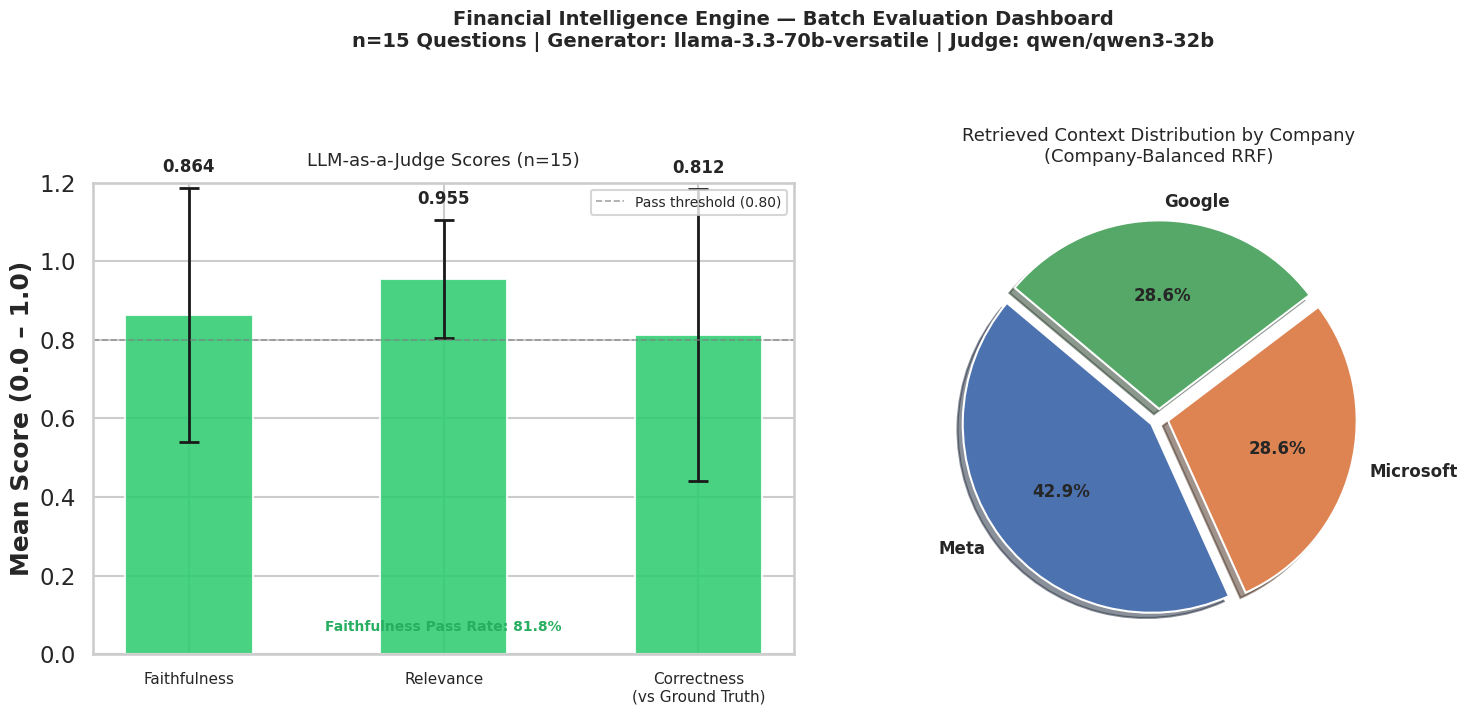

Telemetry dashboard saved: /content/drive/MyDrive/financial-intelligence-engine/artifacts/visualizations/telemetry_dashboard.png


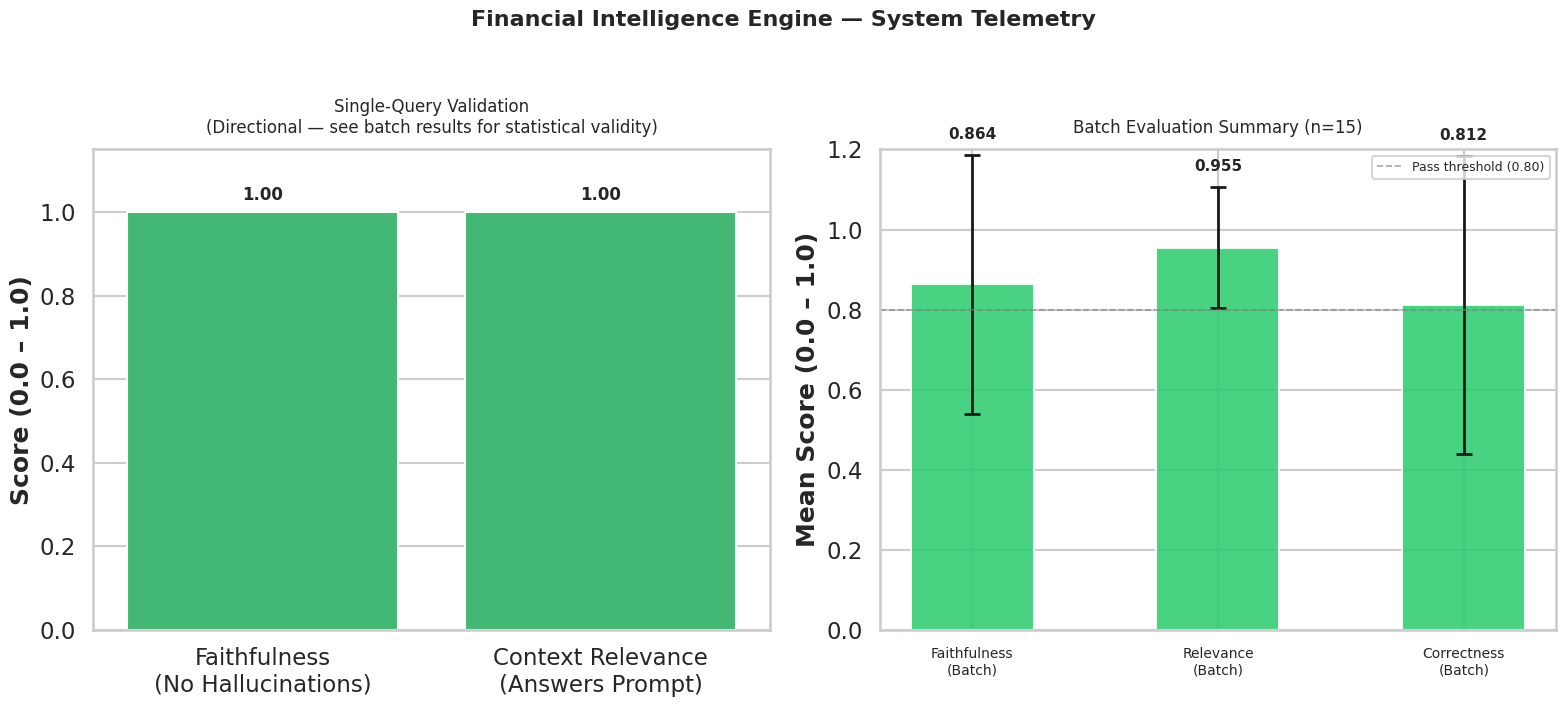


 FINANCIAL INTELLIGENCE ENGINE — FINAL METRICS SUMMARY
  Faithfulness  (n=15) : 0.864 ± 0.323 | Pass rate: 81.8%
  Relevance     (n=15) : 0.955 ± 0.151
  Correctness   (n=15) : 0.812 ± 0.372
  Generator model  : llama-3.3-70b-versatile
  Evaluator model  : qwen/qwen3-32b
  Retrieval method : Hybrid RRF (Dense ChromaDB + Sparse BM25)
  Company balance  : {'Meta': 3, 'Microsoft': 2, 'Google': 2}
All artifacts saved to Google Drive /artifacts/ directory.


In [12]:
# ============================================================
# Cell 6 — Enterprise Visualization & Reporting
# ============================================================
# UPGRADE: Batch evaluation results are now the PRIMARY dashboard.
# Single-query scores are shown as a secondary reference only.
# This ensures the statistically valid n=15 scores are the first
# thing a recruiter or interviewer sees — not a single noisy sample.
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime
from collections import Counter
from src.config import VISUALS_DIR

print("Phase 5: Visualizing Engine Telemetry...")

sns.set_theme(style="whitegrid", context="talk")

# ── DASHBOARD 1: Batch Evaluation Results (PRIMARY) ───────────
# This is the statistically valid result — shown first and largest.
fig1, axes1 = plt.subplots(1, 2, figsize=(16, 7))
fig1.suptitle(
    'Financial Intelligence Engine — Batch Evaluation Dashboard\n'
    f'n={batch_results["n"]} Questions | Generator: {agent.llm.model_name} | '
    f'Judge: {batch_results["evaluator_model"]}',
    fontsize=14, fontweight='bold', y=1.03
)

# ── Plot 1A: Batch Metric Scores with Error Bars ──────────────
batch_metrics = ['Faithfulness', 'Relevance']
batch_means   = [batch_results['mean_faithfulness'], batch_results['mean_relevance']]
batch_stds    = [batch_results['std_faithfulness'],  batch_results['std_relevance']]

if 'mean_correctness' in batch_results:
    batch_metrics.append('Correctness\n(vs Ground Truth)')
    batch_means.append(batch_results['mean_correctness'])
    batch_stds.append(batch_results['std_correctness'])

bar_colors_batch = ['#2ecc71' if m >= 0.8 else '#e74c3c' for m in batch_means]
x_pos = range(len(batch_metrics))

bars = axes1[0].bar(
    x_pos, batch_means, yerr=batch_stds, capsize=7,
    color=bar_colors_batch, alpha=0.88, width=0.5,
    error_kw={'elinewidth': 2, 'capthick': 2}
)
axes1[0].set_xticks(list(x_pos))
axes1[0].set_xticklabels(batch_metrics, fontsize=11)
axes1[0].set_ylim(0, 1.2)
axes1[0].set_ylabel('Mean Score (0.0 – 1.0)', fontweight='bold')
axes1[0].set_title(
    f'LLM-as-a-Judge Scores (n={batch_results["n"]})',
    fontsize=13, pad=12
)
axes1[0].axhline(
    y=0.8, color='gray', linestyle='--', linewidth=1.2,
    alpha=0.7, label='Pass threshold (0.80)'
)
axes1[0].legend(fontsize=10)

# Value labels above bars
for i, (m, s) in enumerate(zip(batch_means, batch_stds)):
    axes1[0].text(
        i, m + s + 0.04, f'{m:.3f}',
        ha='center', fontweight='bold', fontsize=12
    )

# Pass rate annotation
pass_rate = batch_results['faithfulness_pass_rate'] * 100
axes1[0].text(
    0.5, 0.05,
    f'Faithfulness Pass Rate: {pass_rate:.1f}%',
    transform=axes1[0].transAxes,
    ha='center', fontsize=10,
    color='#27ae60' if pass_rate >= 80 else '#e74c3c',
    fontweight='bold'
)

# ── Plot 1B: Retrieved Context Distribution ───────────────────
source_counts = Counter(d.metadata.get('company', 'Unknown') for d in used_docs)
labels = list(source_counts.keys())
sizes  = list(source_counts.values())
explode = [0.05] * len(labels)

axes1[1].pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('deep', len(labels)),
    explode=explode,
    shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'},
)
axes1[1].set_title(
    'Retrieved Context Distribution by Company\n(Company-Balanced RRF)',
    fontsize=13, pad=15
)

plt.tight_layout()
batch_primary_path = f'{VISUALS_DIR}/batch_eval_primary.png'
plt.savefig(batch_primary_path, dpi=300, bbox_inches='tight')
print(f'Primary dashboard saved: {batch_primary_path}')
plt.show()


# ── DASHBOARD 2: System Telemetry (SECONDARY) ─────────────────
# Shows single-query result alongside batch summary for comparison.
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 7))
fig2.suptitle(
    'Financial Intelligence Engine — System Telemetry',
    fontsize=16, fontweight='bold', y=1.02
)

# ── Plot 2A: Single-Query Scores ──────────────────────────────
metric_labels = [
    'Faithfulness\n(No Hallucinations)',
    'Context Relevance\n(Answers Prompt)'
]
score_vals = [
    float(scores.get('faithfulness', 0)),
    float(scores.get('relevance', 0)),
]
bar_colors_single = ['#2ecc71' if s >= 0.8 else '#e74c3c' for s in score_vals]

plot_df = pd.DataFrame({
    'Metric': metric_labels,
    'Score':  score_vals,
    'Color':  bar_colors_single,
})
sns.barplot(
    data=plot_df,
    x='Metric', y='Score',
    hue='Metric',
    palette=dict(zip(metric_labels, bar_colors_single)),
    legend=False,
    ax=axes2[0],
)
axes2[0].set_ylim(0, 1.15)
axes2[0].set_title(
    'Single-Query Validation\n(Directional — see batch results for statistical validity)',
    fontsize=12, pad=12
)
axes2[0].set_ylabel('Score (0.0 – 1.0)', fontweight='bold')
axes2[0].set_xlabel('')

for i, v in enumerate(score_vals):
    axes2[0].text(
        i, v + 0.03, f'{v:.2f}',
        ha='center', fontweight='bold', fontsize=12
    )

# ── Plot 2B: Batch Score Summary Bar ─────────────────────────
summary_metrics = ['Faithfulness\n(Batch)', 'Relevance\n(Batch)']
summary_means   = [batch_results['mean_faithfulness'], batch_results['mean_relevance']]
summary_stds    = [batch_results['std_faithfulness'],  batch_results['std_relevance']]

if 'mean_correctness' in batch_results:
    summary_metrics.append('Correctness\n(Batch)')
    summary_means.append(batch_results['mean_correctness'])
    summary_stds.append(batch_results['std_correctness'])

summary_colors = ['#2ecc71' if m >= 0.8 else '#e74c3c' for m in summary_means]
x2 = range(len(summary_metrics))

axes2[1].bar(
    x2, summary_means, yerr=summary_stds, capsize=6,
    color=summary_colors, alpha=0.88, width=0.5,
    error_kw={'elinewidth': 2, 'capthick': 2}
)
axes2[1].set_xticks(list(x2))
axes2[1].set_xticklabels(summary_metrics, fontsize=10)
axes2[1].set_ylim(0, 1.2)
axes2[1].set_ylabel('Mean Score (0.0 – 1.0)', fontweight='bold')
axes2[1].set_title(
    f'Batch Evaluation Summary (n={batch_results["n"]})',
    fontsize=12, pad=12
)
axes2[1].axhline(
    y=0.8, color='gray', linestyle='--',
    linewidth=1.2, alpha=0.7, label='Pass threshold (0.80)'
)
axes2[1].legend(fontsize=9)

for i, (m, s) in enumerate(zip(summary_means, summary_stds)):
    axes2[1].text(
        i, m + s + 0.04, f'{m:.3f}',
        ha='center', fontweight='bold', fontsize=11
    )

plt.tight_layout()
telemetry_path = f'{VISUALS_DIR}/telemetry_dashboard.png'
plt.savefig(telemetry_path, dpi=300, bbox_inches='tight')
print(f'Telemetry dashboard saved: {telemetry_path}')
plt.show()

# ── Final Summary Print ───────────────────────────────────────
print('\n' + '='*65)
print(' FINANCIAL INTELLIGENCE ENGINE — FINAL METRICS SUMMARY')
print('='*65)
print(f'  Faithfulness  (n={batch_results["n"]}) : '
      f'{batch_results["mean_faithfulness"]:.3f} ± {batch_results["std_faithfulness"]:.3f} '
      f'| Pass rate: {batch_results["faithfulness_pass_rate"]*100:.1f}%')
print(f'  Relevance     (n={batch_results["n"]}) : '
      f'{batch_results["mean_relevance"]:.3f} ± {batch_results["std_relevance"]:.3f}')
if 'mean_correctness' in batch_results:
    print(f'  Correctness   (n={batch_results["n"]}) : '
          f'{batch_results["mean_correctness"]:.3f} ± {batch_results["std_correctness"]:.3f}')
print(f'  Generator model  : {agent.llm.model_name}')
print(f'  Evaluator model  : {batch_results["evaluator_model"]}')
print(f'  Retrieval method : Hybrid RRF (Dense ChromaDB + Sparse BM25)')
print(f'  Company balance  : {dict(Counter(d.metadata.get("company") for d in used_docs))}')
print('='*65)
print('All artifacts saved to Google Drive /artifacts/ directory.')